In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated
import os
from pathlib import Path
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [2]:
env_path = Path(__file__).resolve().parent / ".env" if "__file__" in globals() else Path(".env")
if "OPENROUTER_API_KEY" not in os.environ and env_path.exists():
    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if line and not line.startswith("#") and "=" in line:
            key, value = line.split("=", 1)
            os.environ.setdefault(key.strip(), value.strip().strip("\"").strip("'"))

if "OPENROUTER_API_KEY" in os.environ:
    os.environ.setdefault("OPENAI_API_KEY", os.environ["OPENROUTER_API_KEY"])

try:
    from Backend.llm_router import (
        FALLBACK_MODEL,
        LOCAL_MODEL,
        PRIMARY_MODEL,
        fallback_llm,
        invoke_structured_with_fallback,
        invoke_with_fallback,
        llm,
        local_llm,
        primary_llm,
    )
except ModuleNotFoundError:
    from llm_router import (
        FALLBACK_MODEL,
        LOCAL_MODEL,
        PRIMARY_MODEL,
        fallback_llm,
        invoke_structured_with_fallback,
        invoke_with_fallback,
        llm,
        local_llm,
        primary_llm,
    )

print(f"Writer model: Ollama {LOCAL_MODEL}")
print(f"Structured/fallback models: OpenRouter {PRIMARY_MODEL}, {FALLBACK_MODEL}")

Writer model: Ollama qwen2.5:7b
Structured/fallback models: OpenRouter nvidia/nemotron-3-super-120b-a12b:free, meta-llama/llama-3.3-70b-instruct:free


In [3]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [4]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

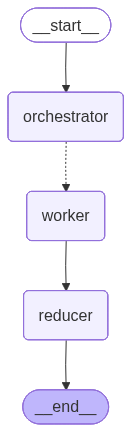

In [5]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [6]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})
print(out["final"])


# Exploring Self Attention: A Deep Dive into Neural Network Mechanism

## Introduction to Self Attention

Self-Attention mechanisms have emerged as a fundamental building block in the realm of neural networks, particularly within Natural Language Processing (NLP). At its core, self-attention enables models to weigh the relevance of different parts of an input when producing an output for each part. This is particularly useful in understanding and processing sequential data, such as text or speech, where capturing long-range dependencies is crucial.

The traditional approach of recurrent neural networks (RNNs) and even their improved variant, Long Short-Term Memory networks (LSTMs), often struggle with learning to retain information over large sequences due to issues like vanishing gradients. Self-attention provides a solution by allowing the model to dynamically focus on different positions in the input sequence, thereby enhancing its ability to capture complex relationships within the